In [1]:
from yaiv import spectrum as spec
%load_ext autoreload
%autoreload 2

# Bands

In [3]:
#bands=spec.electronBands('data/qe/results_bands/Si.bands.pwo')
bands=spec.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
#bands=spec.electronBands('data/vasp/RESULTS/EIGENVAL_BS')

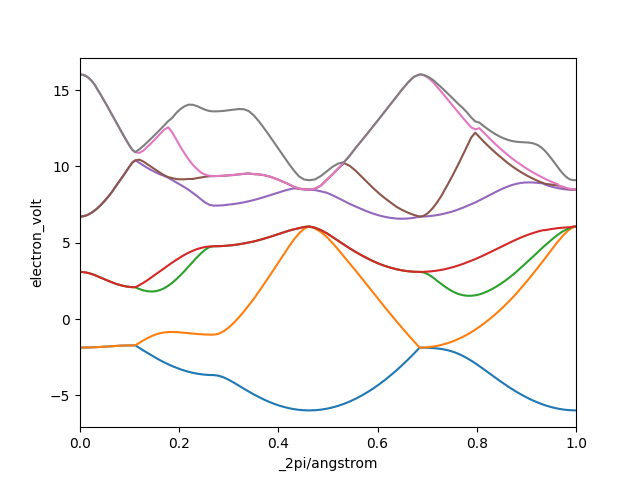

In [4]:
fig,ax=plt.subplots()
bands.plot(ax)
plt.show()

## Fermi level

Fermi level is ill-defined in this case, use gaussian smearing... (also by doing this I can test what they mean by "smearing" in the Gaussian case, a MP of order 0 or a proper Gaussian with σ being the standard deviation)

In [35]:
QE_fermi=bands.fermi
# Obtain DOS and Fermi level
QE_smearing=0.02*ureg.Ry 
bands.get_DOS(smearing=smearing,order=2,precision=5)

<Axes: xlabel='electron_volt', ylabel='DOS(1 / electron_volt)'>

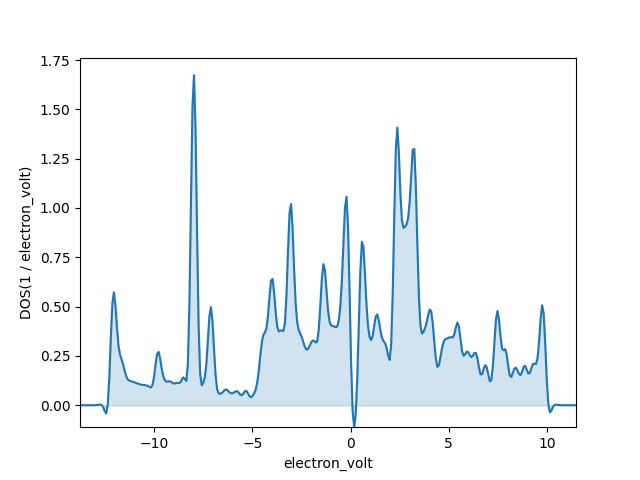

In [37]:
bands.DOS.plot(shift=bands.fermi)

In [28]:
yaiv_fermi,error=bands.DOS.integrate(occ_states=4)

In [43]:
from scipy.integrate import cumulative_trapezoid

In [45]:
Y=cumulative_trapezoid(bands.DOS.DOS,bands.DOS.vgrid)

/u/51/gutierm2/unix/Software/enviroments/yaiv-dev/lib/python3.10/site-packages/scipy/integrate/_quadrature.py:302: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  y = np.asarray(y)
/u/51/gutierm2/unix/Software/enviroments/yaiv-dev/lib/python3.10/site-packages/scipy/integrate/_quadrature.py:308: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.asarray(x)


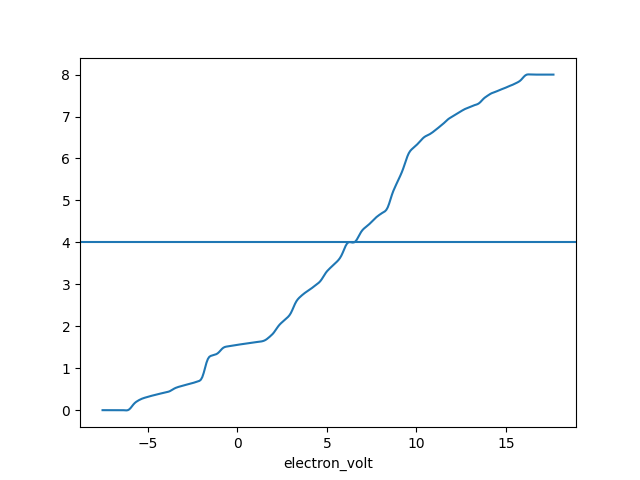

In [48]:
plt.figure()
plt.plot(bands.DOS.vgrid[1:],Y)
plt.axhline(4)
plt.show()

In [29]:
yaiv_fermi

<Quantity(6.25737434, 'electron_volt')>

In [27]:
QE_fermi

<Quantity(6.1725, 'electron_volt')>

In [13]:
bands.electron_num

8

# Phonons

In [6]:
phonons=spec.PhononBands('data/qe/results_matdyn/Si.freq')

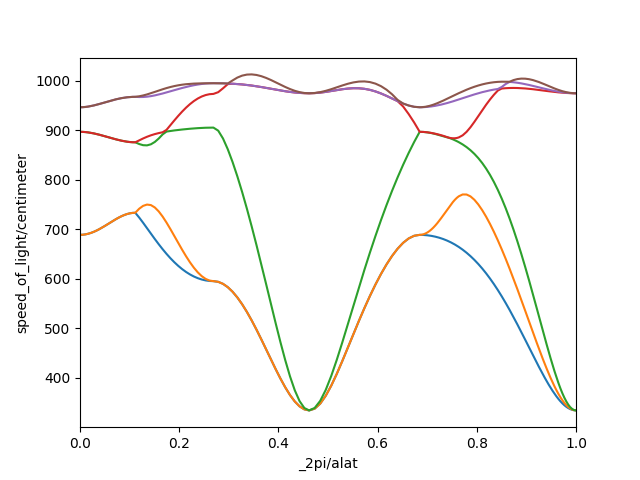

In [7]:
fig,ax=plt.subplots()
phonons.plot(ax)
plt.show()